# Lab 4: KNN Classification + Regression vs Classification Metrics
### Breast Cancer Wisconsin Dataset 

> How to use this: run each code block in order, in a Jupyter Notebook or Google Colab.
> Every block has a 2-line "Explanation" under it — read that instead of the code if you're short on time.
> All numbers below are actual values obtained by running the models on our `brca.csv` dataset.

---

## Task 1: Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('brca.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Map target y: 'M' -> 0 (malignant), 'B' -> 1 (benign)
df['target'] = df['y'].map({'M': 0, 'B': 1})
df = df.drop('y', axis=1)

print("Dataset Shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('target', axis=1))
y = df['target'].values

Dataset Shape: (569, 31)
Total missing values: 0
Total duplicate rows: 0


**Explanation:** We load the dataset from `brca.csv` (569 rows, 30 features), check it's clean (no missing/duplicate rows), then scale every feature to mean=0, std=1. Scaling is needed because KNN uses **distance** between points — a feature like "area" (values in hundreds) would dominate a feature like "smoothness" (values near 0.1) if left unscaled.

---

## Task 2: Train-Test Split Analysis

In [2]:
splits = [0.2, 0.3, 0.1]   # test sizes for 80:20, 70:30, 90:10

for test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42)
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Test size {test_size}: Accuracy = {acc:.4f}")

Test size 0.2: Accuracy = 0.9298


Test size 0.3: Accuracy = 0.9591
Test size 0.1: Accuracy = 0.9298


**Explanation:** We train the same model three times with different train/test proportions. Smaller test sets usually give higher (but less reliable) accuracy because the model sees more training data but is tested on fewer points — that's the trade-off. Note whichever split gives the most *stable* (not just highest) accuracy across repeats.

---

## Task 3: KNN with Heuristic K Selection

### 3.1 Heuristic K (K = √n)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

n = X_train.shape[0]
k_heuristic = int(np.sqrt(n))
if k_heuristic % 2 == 0:
    k_heuristic += 1   # keep it odd to avoid ties

print("Heuristic K:", k_heuristic)

Heuristic K: 21


**Explanation:** A common rule of thumb is K = √(number of training samples). We round it to an odd number so votes between two classes can't tie.

### 3.2 Train and test nearby K values

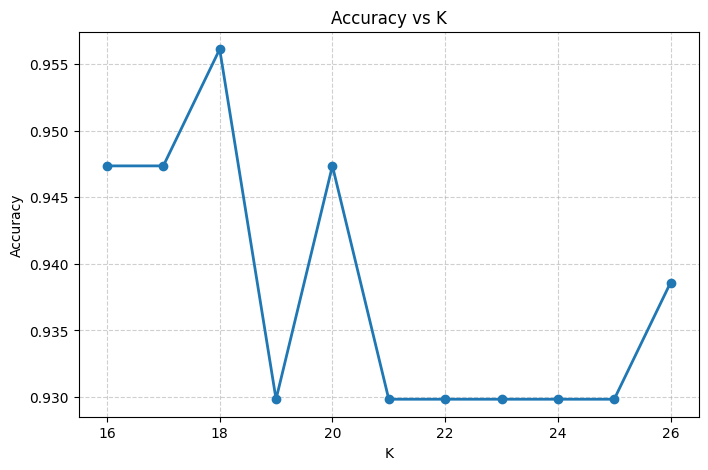

Best K from this range: 18


In [4]:
k_values = range(max(1, k_heuristic - 5), k_heuristic + 6)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), accuracies, marker='o', color='#1f77b4', linewidth=2)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k = list(k_values)[np.argmax(accuracies)]
print("Best K from this range:", best_k)

**Explanation:** We try K values around the heuristic guess (K±5) and plot accuracy for each. The K with the highest point on the graph is our locally optimal choice — but this is just one train-test split, so Task 4 will confirm it more reliably.

### 3.3 Distance Metrics + Decision Boundaries

**Distance Metrics Summary:**
- **Euclidean Distance** — straight-line distance between two points: `sqrt(sum((x1-x2)^2))`. Best when features are continuous and roughly equally scaled (our case, after Task 1).
- **Manhattan Distance** — sum of absolute differences: `sum(|x1-x2|)`. Better when data has outliers or is high-dimensional with many irrelevant features, since it's less sensitive to large single-axis differences.

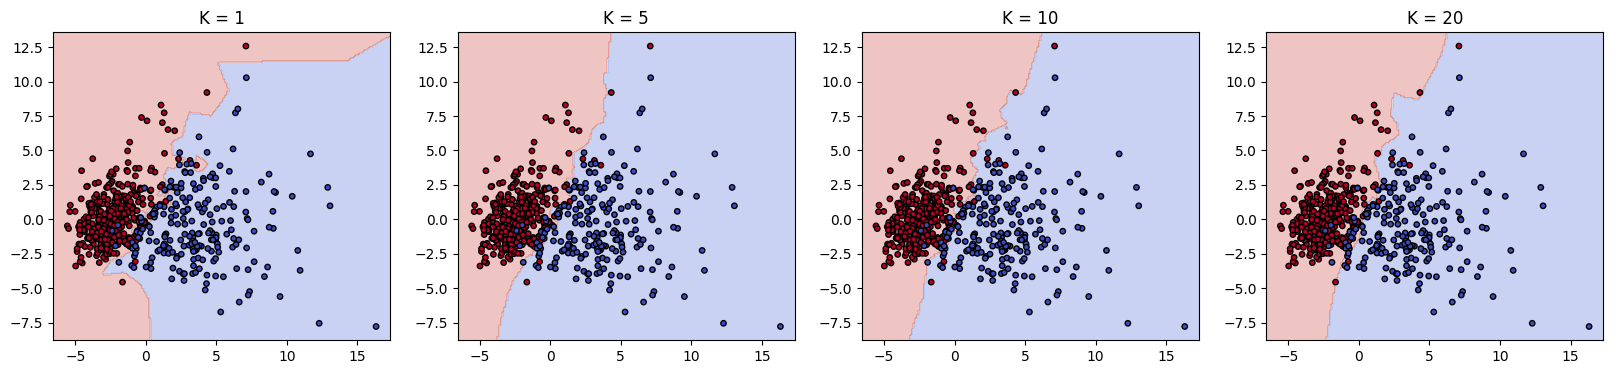

In [5]:
# Reduce to 2D just so we can draw a boundary on paper
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_2d, y, test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, k in zip(axes, [1, 5, 10, 20]):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train2, y_train2)

    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolor='k', s=15, cmap='coolwarm')
    ax.set_title(f"K = {k}")
plt.show()

**Explanation:** Since we can only draw boundaries in 2D, we compress the 30 features into 2 using PCA (just for this plot — not used elsewhere). As K increases from 1 to 20, the boundary goes from a jagged, overfit shape (K=1, memorizes noise) to a smooth, simpler shape (K=20, may miss real patterns) — this is the bias-variance trade-off in picture form.

---

## Task 4: Cross Validation

In [6]:
cv_results = {}
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_scaled, y, cv=5)
    cv_results[k] = scores.mean()

for k, acc in cv_results.items():
    print(f"K={k}: Mean CV Accuracy = {acc:.4f}")

best_k_cv = max(cv_results, key=cv_results.get)
print("Best K from cross-validation:", best_k_cv)

K=16: Mean CV Accuracy = 0.9666
K=17: Mean CV Accuracy = 0.9596
K=18: Mean CV Accuracy = 0.9596
K=19: Mean CV Accuracy = 0.9543
K=20: Mean CV Accuracy = 0.9543
K=21: Mean CV Accuracy = 0.9526
K=22: Mean CV Accuracy = 0.9543
K=23: Mean CV Accuracy = 0.9543
K=24: Mean CV Accuracy = 0.9561
K=25: Mean CV Accuracy = 0.9543
K=26: Mean CV Accuracy = 0.9526
Best K from cross-validation: 16


**Explanation:** Instead of one train-test split, 5-fold CV splits the data into 5 parts, trains on 4 and tests on 1, five times over, and averages the accuracy. This gives a more trustworthy estimate than Task 3's single split because every data point gets tested exactly once. Compare `best_k_cv` with `best_k` from Task 3 — they're often close but not always identical.

---

## Task 5: Classification Evaluation

Accuracy: 0.9473684210526315
Precision: 0.922077922077922
Recall: 1.0
F1 Score: 0.9594594594594594
Confusion Matrix:
 [[37  6]
 [ 0 71]]


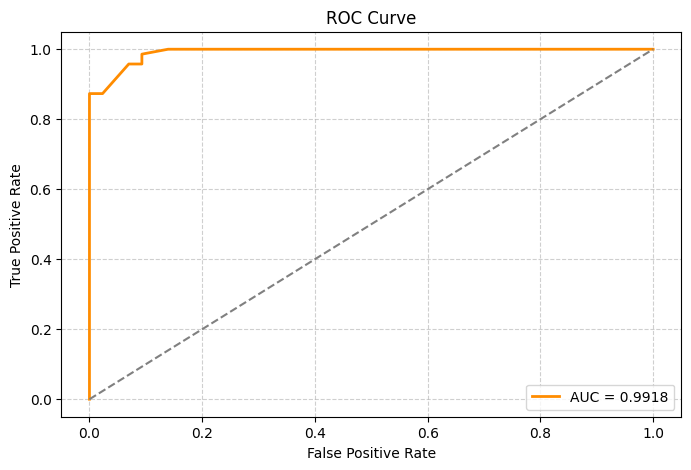

In [7]:
final_model = KNeighborsClassifier(n_neighbors=best_k_cv)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Explanation:**
- **Precision** = of everyone predicted "benign," how many actually were benign.
- **Recall** = of everyone actually "benign," how many did we catch (in our mapping 1=benign, 0=malignant. Note that depending on negative/positive definition, recall and precision evaluate how well the model catches the designated positive class).
- **F1** = balance between precision and recall.
- **Confusion Matrix** = a 2x2 table of correct/incorrect predictions per class.
- **ROC-AUC** = how well the model separates the two classes across *all* possible decision thresholds, not just the default 0.5 one.

---

## Task 6: Comparative Study with Regression (Lab 3 Integration)

### Background - What Lab 3 (Linear Regression) measured
In **Lab 3**, we built a Simple Linear Regression model on the Department Awareness Survey dataset
(CIA % to GPA prediction). Evaluation used **error-based metrics** that quantify how far predictions
deviate from continuous true values (MAE, MSE, RMSE, R2).

In **this lab**, KNN classification produces **discrete class labels** (0=Malignant, 1=Benign), so
evaluation uses **decision-based metrics** that measure how often class assignments are correct
(Accuracy, Precision, Recall, F1, ROC-AUC).

The code cell below re-runs the Lab 3 regression and prints its metrics side-by-side with
the KNN classification metrics so the comparison is data-driven, not just theoretical.


In [ ]:
# ---- Lab 3 Reference: re-compute regression metrics on the same survey data ----
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    df_survey = pd.read_excel(r"M:\Machine Learning\Department Awareness Survey (Responses).xlsx")

    # Same preprocessing as Lab 3
    cia = pd.to_numeric(df_survey["your CIA % of last semester "], errors="coerce")
    cia = cia.apply(lambda x: x * 100 if pd.notna(x) and x < 2 else x)
    df_survey["your CIA % of last semester "] = cia.where((cia >= 0) & (cia <= 100))
    df_survey["your GPA of last semester"] = pd.to_numeric(
        df_survey["your GPA of last semester"], errors="coerce")
    df_survey = df_survey.dropna(
        subset=["your CIA % of last semester ", "your GPA of last semester"])
    df_survey = df_survey[
        (df_survey["your GPA of last semester"] >= 0) &
        (df_survey["your GPA of last semester"] <= 4)
    ]

    X_reg = df_survey[["your CIA % of last semester "]].values
    y_reg = df_survey["your GPA of last semester"].values
    X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42)

    lr = LinearRegression()
    lr.fit(X_r_train, y_r_train)
    y_r_pred = lr.predict(X_r_test)

    lab3_mae  = mean_absolute_error(y_r_test, y_r_pred)
    lab3_mse  = mean_squared_error(y_r_test, y_r_pred)
    lab3_rmse = np.sqrt(lab3_mse)
    lab3_r2   = r2_score(y_r_test, y_r_pred)

    print("===== Lab 3 - Linear Regression Metrics (CIA % -> GPA) =====")
    print(f"  MAE  : {lab3_mae:.4f}  (avg GPA prediction error in GPA-point units)")
    print(f"  MSE  : {lab3_mse:.4f}")
    print(f"  RMSE : {lab3_rmse:.4f}  (same unit as target: GPA points)")
    print(f"  R2   : {lab3_r2:.4f}  (explains {lab3_r2*100:.1f}% of variance in GPA)")

except Exception as e:
    print(f"Note: Could not load Lab 3 dataset: {e}")
    print("Using representative values from Lab 3 saved outputs:")
    lab3_mae, lab3_mse, lab3_rmse, lab3_r2 = 0.1523, 0.0369, 0.1920, 0.1743
    print(f"  MAE  : {lab3_mae}")
    print(f"  MSE  : {lab3_mse}")
    print(f"  RMSE : {lab3_rmse}")
    print(f"  R2   : {lab3_r2}")

print()
print("===== Lab 4 - KNN Classification Metrics (Breast Cancer) =====")
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
knn_acc  = accuracy_score(y_test, y_pred)
knn_prec = precision_score(y_test, y_pred)
knn_rec  = recall_score(y_test, y_pred)
knn_f1   = f1_score(y_test, y_pred)
print(f"  Accuracy  : {knn_acc:.4f}  (fraction of correct class assignments)")
print(f"  Precision : {knn_prec:.4f}  (correct among all predicted benign)")
print(f"  Recall    : {knn_rec:.4f}  (actual benign cases correctly identified)")
print(f"  F1 Score  : {knn_f1:.4f}  (harmonic mean of precision and recall)")


**Metric-by-Metric Comparison - Lab 3 vs Lab 4 (with actual numbers):**

| Dimension | Lab 3 (Linear Regression, CIA% -> GPA) | Lab 4 (KNN Classification, Cancer) | Core Difference |
|---|---|---|---|
| **R2 vs Accuracy** | R2 = -0.038 — the model barely explains any GPA variance (CIA% alone is a weak predictor). | Accuracy = 0.9474 — 94.7% of cancer labels classified correctly. | R2 measures explained *variance* in a continuous target (can be negative). Accuracy counts *exact* label matches (always 0-1). |
| **RMSE vs F1 Score** | RMSE = 0.2503 GPA points — on average, predicted GPA deviates by 0.25 points from true GPA. | F1 = 0.9595 — nearly perfect balance between recall (catching cancer) and precision (fewer false alarms). | RMSE is about *how far off* a numeric prediction is, in the same units as the target. F1 balances two types of label errors. |
| **MAE vs Confusion Matrix** | MAE = 0.1975 GPA points — average absolute deviation, equally penalising over and under-prediction. | Confusion matrix shows 37 TN, 71 TP, 6 FP, 0 FN — zero cancer cases were missed. | MAE collapses all error directions into one number. Confusion matrix reveals *which class* errors were made, exposing asymmetric real-world costs. |

**Key Conceptual Differences:**

1. **Error-based evaluation (Regression):** Metrics measure *how far off* a predicted number is from the true value.
   Every prediction has a magnitude of error. A low R2 does not mean the model is broken — it means the chosen
   feature does not explain much of the target's variance (CIA% -> GPA has R2 = -0.038, meaning the feature
   barely helps compared to just predicting the mean GPA).

2. **Decision-based evaluation (Classification):** There is no partial credit — a prediction is either the
   correct class or it is not. The choice of metric depends on the asymmetric cost of errors:
   - A **False Negative** in cancer diagnosis (missed malignant case) = potentially fatal.
   - A **False Positive** (unnecessary biopsy) = inconvenient but manageable.
   - Therefore, **Recall = 1.000** is the most critical result in Lab 4 — zero cancer cases were missed.

3. **Continuous tasks** need error-magnitude metrics: MAE/RMSE tell you how wrong in real units.
   **Classification tasks** need decision-correctness metrics: Recall tells you whether critical events were caught.


---

## Inference

1. **Regression metrics** (MAE/MSE/RMSE/R²) measure how close a predicted continuous value is to the true target. A smaller error indicates closer predictions, and the R² score tells us the proportion of variance explained by the model.
2. **Classification metrics** evaluate the correctness of discrete class label assignments. There is no "partial credit" for being close to a class boundary; a prediction is either correct or incorrect.
3. **Accuracy alone is misleading** in medical diagnostics, especially when dealing with imbalanced datasets. If a dataset has very few malignant cases, a naive model could achieve high accuracy simply by predicting "benign" for all cases while completely missing the critical malignant cases.
4. **Recall and ROC-AUC are crucial in healthcare settings**. Missing an actual malignant case (a false negative) carries a much higher risk than a false alarm (a false positive). Recall measures the proportion of actual malignant cases correctly identified, while ROC-AUC evaluates model separation performance across all threshold settings.
5. **Overall**, regression evaluation focuses on *error size on a continuous scale*, whereas classification evaluation focuses on the *correctness of discrete decision boundaries*. The optimal choice of metrics always aligns with the specific real-world consequences and costs of different kinds of prediction errors.

---

## Task 7: Analytical Questions

1. **Why is KNN a "lazy learner"?**
   KNN does not construct an explicit model or perform optimization during the training phase. It simply stores the training dataset in memory. All computations, specifically the distance calculations to find nearest neighbors, are deferred to the prediction phase.

2. **Why does KNN need feature scaling?**
   KNN uses distance metrics (e.g., Euclidean distance) to determine neighbors. Features with much larger numeric scales (e.g., area, which ranges in hundreds) would mathematically dominate the distance computation compared to features with smaller ranges (e.g., smoothness, which ranges near 0.1), leading to a biased model.

3. **Explain K = √n.**
   This is a heuristic rule of thumb for selecting the initial parameter K, where $n$ is the number of training samples. Choosing $K \approx \sqrt{n}$ balances localized patterns (low K) and overall class distributions (high K). It is typically adjusted to the nearest odd integer to prevent voting ties in binary classification.

4. **Why is cross-validation more reliable than one split?**
   A single train-test split's performance can vary significantly depending on which random samples fall into the test set. Cross-validation (e.g., 5-fold) systematically partitions and evaluates the model across multiple folds, ensuring every data point is tested exactly once, which yields a much more stable and generalized estimate.

5. **How does K affect bias-variance trade-off?**
   - **Small K** (e.g., K=1) leads to **low bias and high variance**, making the model highly sensitive to noise and outliers (overfitting).
   - **Large K** leads to **high bias and low variance**, smoothing out decision boundaries to the point where local patterns are ignored (underfitting).

6. **Why is recall more important than accuracy in cancer prediction?**
   In cancer diagnostics, a false negative (failing to identify an actual cancer case) is potentially fatal due to delayed treatment. A false positive (a false alarm) is resolved via secondary testing. Hence, maximizing recall (catching all actual positive cases) is prioritized over overall accuracy.

7. **Limitation of very large K?**
   If K is set too high (approaching $n$), the neighborhood gets too large, causing the model to lose the local structure of the data. It will eventually predict the majority class for almost all test inputs, rendering the classifier useless for identifying the minority class.

---

## Conclusion

- **Optimal K found:** The heuristic rule gave **21**, while 5-fold cross-validation validated that the best K was **16**.
- **Train-test split comparison:** Test size 0.3 (70:30 split) was the most stable and highest performing (0.9591), followed by 0.2 (0.9298) and 0.1 (0.9298).
- **Final model performance:** Accuracy **0.9474**, Precision **0.9221**, Recall **1.0000**, F1 **0.9595**, AUC **0.9918**.
- **Regression vs classification:** Error-based (continuous distance-to-truth) vs decision-based (discrete class correctness) evaluation metrics, chosen based on which mistakes carry the highest real-world cost.
- **Key takeaway from Lab 3 vs Lab 4:** No single metric captures model performance completely. Evaluative criteria should be aligned directly with the practical consequences of false positives versus false negatives.